# Figure

Behavior of $Z(p)$ as a function of $p$. We can see various values of $N$ (number of agents) and $B$ (bar capacity). In all cases, $\mu = 0.5$. The dashed vertical line indicates $p = \mu = 0.5$, and the horizontal dashed line represents $Z(p) = 0$. The intersection points with the horizontal axis correspond to the equilibrium condition, and the peak points to the optimal value of $Z$ at the optimal probability $p^*$.

In [7]:
import sys

sys.path.append('../src')

In [8]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from bayes_opt import BayesianOptimization

from config.config import PATHS
from analysis.z_bayesian import Z, p_maximizing_Z

In [9]:
from analysis.z_bayesian import Z, p_maximizing_Z
result = p_maximizing_Z(N=100, B=50, init_points=8, n_iter=25)
p_star = result["p"]
z_max = result["Z"]

print(p_star, z_max)

0.401933309689558 38.256330101452626


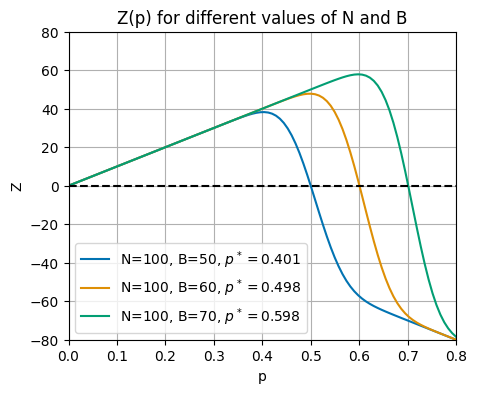

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
palette = sns.color_palette('colorblind', 6)
maximo = 0.8
N = 100
for i, mu in enumerate([0.5, 0.6, 0.7]):
	B = int(N * mu)
	p_star = p_maximizing_Z(N, B, init_points=10, n_iter=10, verbose=0)["p"]
	X = np.linspace(0, maximo, 100)
	Y = [Z(p, N, B) for p in X]
	label = fr'N={N}, B={B}, $p^*={p_star:.3f}$'
	sns.lineplot(x=X, y=Y, label=label, color=palette[i], ax=ax)
ax.hlines(0, 0, maximo, color='black', linestyle='--')
# ax.vlines(mu, -N, N, color='black', linestyle='--')
ax.set_xlabel('p')
ax.set_ylabel('Z')
ax.set_title(r'Z(p) for different values of N and B')
ax.set_xlim([0, 0.8])
ax.set_ylim([-80, 80])
ax.grid()
ax.legend()

In [20]:
fig.savefig(PATHS['graphs'] / 'p_star.png', dpi=300)